In [1]:
import os
import cv2
import sklearn
import pandas as pd
import numpy as np,random
import seaborn as sn
import tensorflow as tf
from sklearn.svm import SVC
from keras.optimizers import Adam
from sklearn.utils import shuffle
from sklearn.svm import LinearSVC
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import BatchNormalization,MaxPooling2D,Conv2D,Flatten,Dense,Dropout


In [2]:
path_of_dir=os.listdir('../brain tumor/')
classes_in_dir={'Healthy':0,'Brain Tumor':1}

classes_in_dir

{'Healthy': 0, 'Brain Tumor': 1}

In [3]:
import cv2
import numpy as np

def safe_augment(img):
    h, w = img.shape[:2]

    # 1. Fixed rotation (e.g., 5 degrees)
    angle = 5
    M_rot = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    img = cv2.warpAffine(img, M_rot, (w, h), borderMode=cv2.BORDER_REFLECT)

    # 2. Fixed zoom (e.g., 1.05x)
    zf = 1.05
    zh, zw = int(h*zf), int(w*zf)
    img = cv2.resize(img, (zw, zh))
    start_y = max((zh - h)//2, 0)
    start_x = max((zw - w)//2, 0)
    img = img[start_y:start_y+h, start_x:start_x+w]

    # 3. Fixed brightness (+10)
    beta = 10
    img = cv2.convertScaleAbs(img, alpha=1.0, beta=beta)

    # 4. Fixed gamma (1.05)
    gamma = 1.05
    img = np.power(img / 255.0, gamma) * 255
    img = img.astype(np.uint8)

    # 5. Always apply Gaussian blur
    img = cv2.GaussianBlur(img, (3, 3), 0)

    # 6. Always flip horizontally
    img = cv2.flip(img, 1)

    return img



X, Y = [], []

for i in classes_in_dir:
    path = '../brain tumor/' + i
    for j in os.listdir(path):
        pic = cv2.imread(path + '/' + j, cv2.IMREAD_GRAYSCALE)  # Force grayscale
        pic = cv2.resize(pic, (200, 200))                       # Force size
        pic = safe_augment(pic)
        pic = np.array(pic, dtype='float32')
        if pic.shape != (200, 200):
            pic = cv2.resize(pic, (200, 200))

        X.append(pic)
        Y.append(classes_in_dir[i])

       


In [4]:
x = np.array(X, dtype='float32').reshape(-1, 200, 200, 1) / 255.0  # normalize
y = np.array(Y)
x, y = shuffle(x, y, random_state=42)

In [5]:
pd.Series(y).value_counts()

0    2500
1    2500
Name: count, dtype: int64

In [6]:
y.shape

(5000,)

In [7]:
x.shape

(5000, 200, 200, 1)

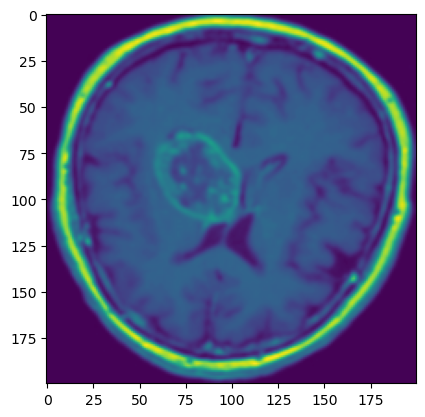

In [8]:
plt.imshow(x[1])


In [9]:
x.shape

(5000, 200, 200, 1)

In [10]:
x_train3D,x_test3D,y_train3D,y_test3D=train_test_split(x ,y,random_state=42,test_size=0.20)

Text(0.5, 0, '0')

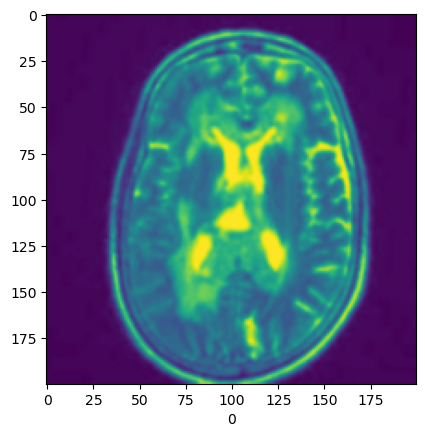

In [11]:
plt.imshow(x_test3D[5])
plt.xlabel(y_test3D[5])


In [12]:
x_train3D.shape

(4000, 200, 200, 1)

#CNN MODEL

In [13]:
cnn=Sequential([keras.layers.Input(shape=(200,200,1)),
Conv2D(filters=32, kernel_size=(3, 3), activation='relu'), # convolutional layer
BatchNormalization(),
MaxPooling2D(), # pooling layer

Conv2D(filters=64, kernel_size=(3, 3), activation='relu'), # convolutional layer
BatchNormalization(),
MaxPooling2D(), # pooling layer

Flatten(),
Dense(1, activation='sigmoid')

])

cnn.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 198, 198, 32)      320       
                                                                 
 batch_normalization (BatchN  (None, 198, 198, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 99, 99, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 97, 97, 64)        18496     
                                                                 
 batch_normalization_1 (Batc  (None, 97, 97, 64)       256       
 hNormalization)                                                 
                                                        

In [14]:
cnn.compile(optimizer=Adam(learning_rate=1e-4),loss='binary_crossentropy', metrics=['accuracy'])

In [15]:
cnn.fit(x_train3D,y_train3D,validation_data=(x_test3D,y_test3D), epochs=3, batch_size=16)

Epoch 1/3
250/250 [==============================] - 74s 292ms/step - loss: 0.4591 - accuracy: 0.8443 - val_loss: 0.6402 - val_accuracy: 0.5440
Epoch 2/3
250/250 [==============================] - 73s 290ms/step - loss: 0.1390 - accuracy: 0.9510 - val_loss: 0.2009 - val_accuracy: 0.9280
Epoch 3/3
250/250 [==============================] - 72s 289ms/step - loss: 0.0518 - accuracy: 0.9830 - val_loss: 0.1294 - val_accuracy: 0.9570


In [16]:
test_loss,test_acc=cnn.evaluate(x_test3D,y_test3D,verbose=2)

32/32 - 4s - loss: 0.1294 - accuracy: 0.9570 - 4s/epoch - 140ms/step


In [17]:
pred1=(cnn.predict(x_test3D)>0.5).astype('int').flatten()

32/32 [==============================] - 5s 140ms/step


In [18]:
print(pred1[0:20])

[0 1 0 1 1 0 1 1 0 1 0 0 0 1 1 0 0 1 0 1]


In [19]:
accuracy_score(y_test3D,pred1)

0.957

In [20]:
conf_mat= confusion_matrix(y_test3D,pred1)
print(classification_report(y_test3D,pred1))


              precision    recall  f1-score   support

           0       0.96      0.95      0.95       476
           1       0.95      0.97      0.96       524

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



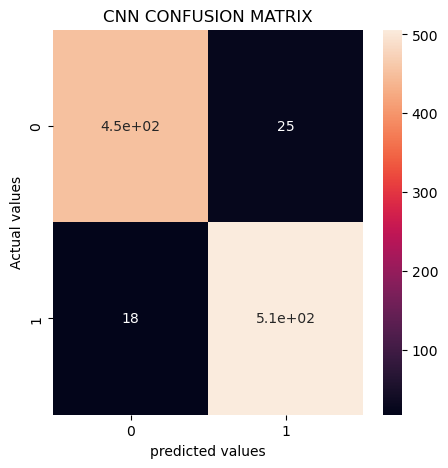

In [21]:
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("CNN CONFUSION MATRIX")
plt.show()

#Random forest

In [22]:
x_updated=x.reshape(len(x),-1)

In [23]:
x_updated.shape

(5000, 40000)

In [24]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_updated)

In [25]:
x_train2D,x_test2D,y_train2D,y_test2D=train_test_split(x_scaled,y,random_state=42,test_size=0.20)

In [26]:
x_train2D.shape

(4000, 40000)

In [27]:
rf= RandomForestClassifier()
rf.fit(x_train2D, y_train2D)

RandomForestClassifier()

In [28]:
pred2=rf.predict(x_test2D)

In [29]:
accuracy_score(y_test2D,pred2)

0.952

In [30]:

conf_mat2=confusion_matrix(y_test2D,pred2)


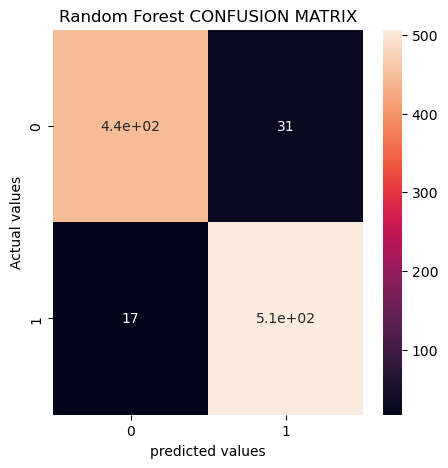

In [31]:
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat2,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Random Forest CONFUSION MATRIX")
plt.show()

#SVM

In [32]:
svm_pipeline = Pipeline([
    ('pca', PCA(n_components=1000)),        # reduce to 500 features
    ('svm', LinearSVC(C=1.0, max_iter=2000, tol=1e-3))  # fewer iterations needed
])

svm_pipeline.fit(x_train2D, y_train2D)
pred3 =svm_pipeline.predict(x_test2D)



In [33]:
accuracy_score(y_test2D,pred3)

0.907

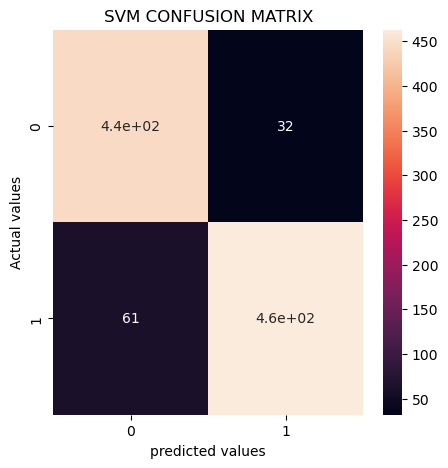

In [34]:
conf_mat3=confusion_matrix(y_test2D,pred3)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat3,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("SVM CONFUSION MATRIX")
plt.show()

#KNN

In [35]:
knn =KNeighborsClassifier(n_neighbors=5, weights='distance')
knn.fit(x_train2D, y_train2D) 

KNeighborsClassifier(weights='distance')

In [36]:
pred4=knn.predict(x_test2D)

In [37]:
#evaluting the model
accuracy_score(y_test2D,pred4)

0.932

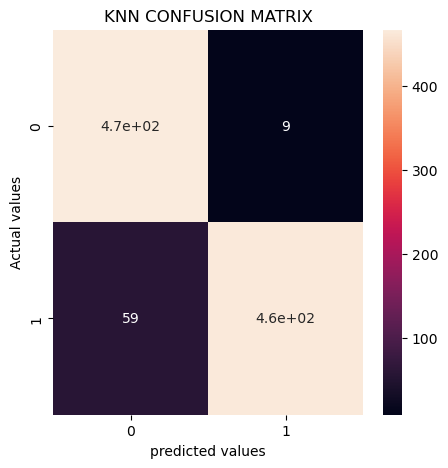

In [38]:
conf_mat4=confusion_matrix(y_test2D,pred4)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat4,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("KNN CONFUSION MATRIX")
plt.show()

#Logistic Regression

In [39]:
LR = LogisticRegression(max_iter=10000, solver='lbfgs')
LR.fit(x_train2D, y_train2D)

LogisticRegression(max_iter=10000)

In [40]:
pred5 = LR.predict(x_test2D)

print("Accuracy:", accuracy_score(y_test2D, pred5))
print("\nClassification Report:\n", classification_report(y_test2D, pred5))

Accuracy: 0.926

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.94      0.92       476
           1       0.94      0.92      0.93       524

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



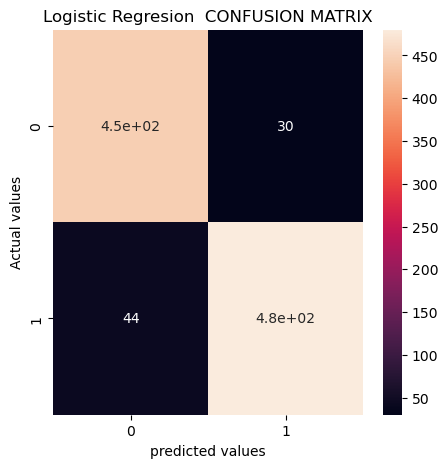

In [41]:
conf_mat5= confusion_matrix(y_test2D,pred5)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat5,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Logistic Regresion  CONFUSION MATRIX")
plt.show()

# ALL PREDICTED VALUES

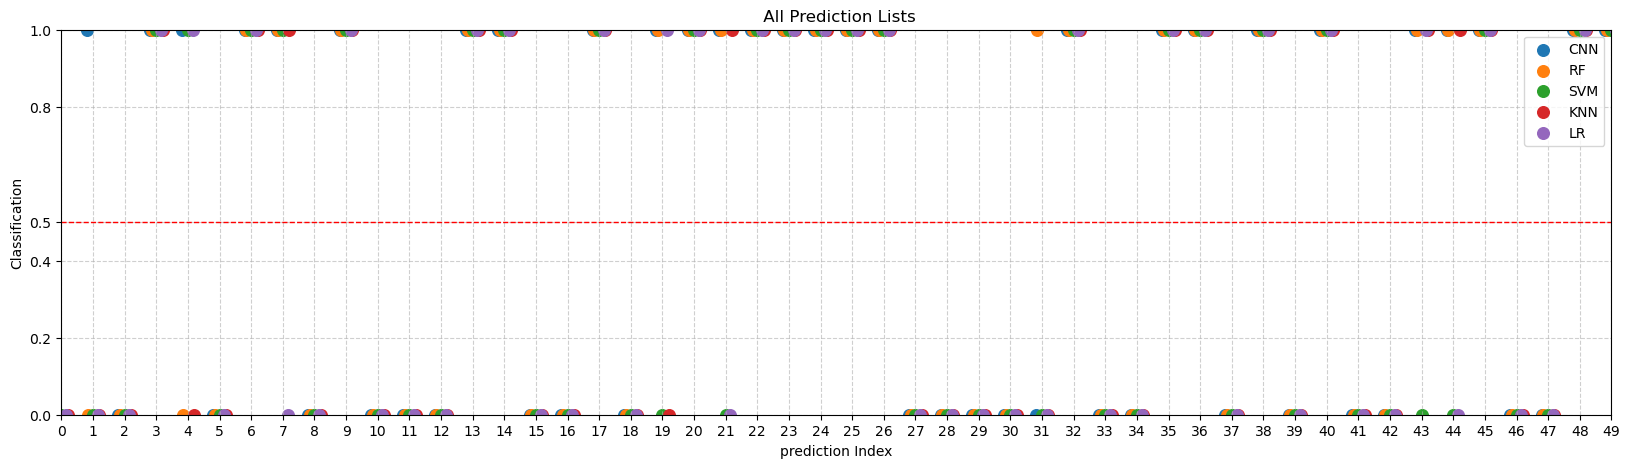

In [42]:
sze=np.arange(len(pred1))
plt.figure(figsize=(20,5))
plt.scatter(sze - 0.2, pred1, label='CNN', alpha=1, s=70)
plt.scatter(sze - 0.15, pred2, label='RF', alpha=1, s=70)
plt.scatter(sze, pred3, label='SVM', alpha=1, s=70)
plt.scatter(sze + 0.2, pred4, label='KNN', alpha=1, s=70)
plt.scatter(sze + 0.15 , pred5, label='LR', alpha=1, s=70)

plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1)

plt.ylim(0,1)
plt.xlim(0,10)
plt.xticks(range(0,50))
plt.yticks([0, 0.2,0.4,0.5,0.8,1])
plt.xlabel('prediction Index')
plt.ylabel('Classification')
plt.title(' All Prediction Lists')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


In [43]:
pp1=(cnn.predict(x_test3D)>0.5).astype('int').flatten()
pp2=rf.predict(x_test2D)
pp3=svm_pipeline.predict(x_test2D)
pp4=knn.predict(x_test2D)
pp5=LR.predict(x_test2D)

32/32 [==============================] - 4s 134ms/step


In [44]:
print(pp1[0:2])

[0 1]


In [45]:
total_prediction=[]
for i in range(len(pp3)):
    totaladd=pp1[i]+pp2[i]+pp3[i]+pp4[i]+pp5[i]
    total_prediction.append(totaladd)


In [46]:
Ensemble_prediction = [1 if val >= 3 else 0 for val in total_prediction]
print(Ensemble_prediction[:6])

[0, 0, 0, 1, 1, 0]


In [47]:
print(y_test2D[0:6])

[0 0 0 1 1 0]


In [48]:
print(pred1[0:6])

[0 1 0 1 1 0]


In [49]:
print(pred2[0:6])

[0 0 0 1 0 0]


In [50]:
print(pred3[0:6])

[0 0 0 1 1 0]


In [51]:
print(pred4[0:6])

[0 0 0 1 0 0]


In [52]:
print(pred5[0:6])

[0 0 0 1 1 0]


In [53]:
g=np.where(y_test2D != Ensemble_prediction)[0]
print(g)

[ 56  94  96 113 117 139 199 261 325 385 388 444 525 574 602 632 637 670
 678 688 706 707 721 738 757 774 783 828 829 882 905 909 914 934 945 978
 981]


In [54]:
print("Accuracy:", accuracy_score(y_test2D, Ensemble_prediction))
print("\nClassification Report:\n", classification_report(y_test2D, Ensemble_prediction))

Accuracy: 0.963

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.96       476
           1       0.96      0.97      0.96       524

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



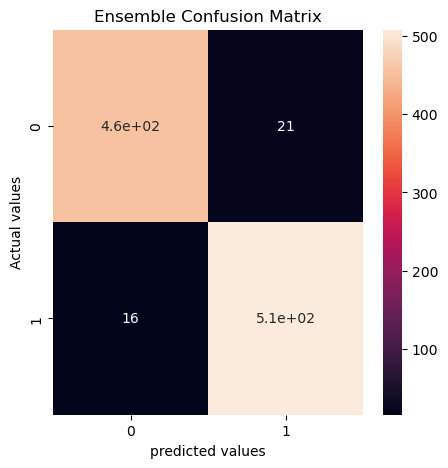

In [55]:
ensemble_confusion_matrix= confusion_matrix(y_test2D,Ensemble_prediction)
plt.figure(figsize=(5,5))
sn.heatmap(ensemble_confusion_matrix,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Ensemble Confusion Matrix")
plt.show()

In [56]:
x_pred, y_pred = [], []
img_path = r"D:\My Final Work\external_pic" 
for j in os.listdir(img_path):
        pic = cv2.imread(img_path + '/' + j, cv2.IMREAD_GRAYSCALE)  # Force grayscale
        pic = cv2.resize(pic, (200, 200))                       # Force size
        pic = np.array(pic, dtype='float32')
        if pic.shape != (200, 200):
            pic = cv2.resize(pic, (200, 200))

        x_pred.append(pic)
        y_pred.append(j)


(-0.5, 199.5, 199.5, -0.5)

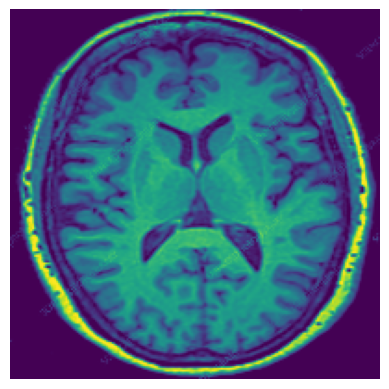

In [57]:
plt.imshow(x_pred[1])
plt.axis('off')

In [69]:
ensemble_data = []

for k in os.listdir(img_path):
    file_path = os.path.join(img_path, k)

    # ---- Load image ----
    img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (200, 200))

    # CNN Prediction
    cnnpred1 = img.reshape(1, 200, 200, 1) / 255.0
    ap11 = (cnn.predict(cnnpred1) > 0.5).astype('int').flatten()[0]

    # Traditional models
    changeto2d = img.reshape(1, -1)   # flatten
    img_TM = scaler.transform(changeto2d)   # only transform, don't fit

    ap22 = rf.predict(img_TM)[0]
    ap33 = svm_pipeline.predict(img_TM)[0]
    ap44 = LR.predict(img_TM)[0]
    ap55 = knn.predict(img_TM)[0]
 
   # Print results
   #print("name of im:", file_path)
   # print("CNN =", ap11)
   # print("RF  =", ap22)
   # print("SVM =", ap33)
   # print("LR  =", ap44)
   # print("KNN =", ap55)
 
    
    votes = ap11 + ap22 + ap33 + ap44 + ap55
    if votes >= 3:
        ensemble_data.append(("Tumor", k))
        #print(" Tumor\n")
    else:
        ensemble_data.append(("No Tumor", k))
        #print(" No Tumor\n")
print(ensemble_data)


1/1 [==============================] - 0s 26ms/step
[('No Tumor', '1.jpg'), ('Tumor', '10.jpg'), ('No Tumor', '11.png'), ('No Tumor', '12.jpg'), ('No Tumor', '13.jpeg'), ('Tumor', '2.jpeg'), ('Tumor', '3.jpg'), ('No Tumor', '4.png'), ('No Tumor', '5.png'), ('Tumor', '6.jpeg'), ('Tumor', '7.jpeg'), ('Tumor', '8.jpg'), ('Tumor', '9.jpg')]


In [70]:
img_path2 = r"D:\My Final Work\external_pic/1.jpg" 
pic1 = cv2.imread(img_path2,0)  # Force grayscale
pic1= cv2.resize(pic1, (200, 200))                       # Force size


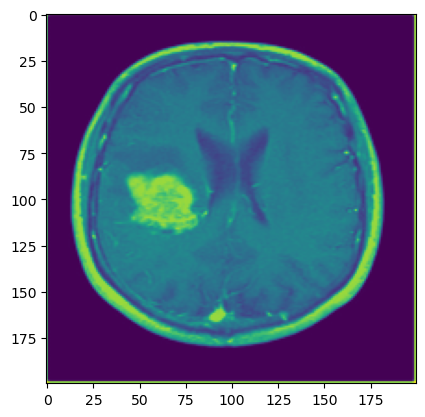

In [71]:
plt.imshow(pic1)

In [72]:
cnnpred1=safe_augment(pic1)

In [73]:
cnnpred1 = pic1.reshape(1, 200, 200, 1)
cnnpred = cnnpred1 / 255.0

In [74]:
cnnpred.shape

(1, 200, 200, 1)

In [75]:
p11 = (cnn.predict(cnnpred) > 0.5).astype('int').flatten()

1/1 [==============================] - 0s 39ms/step


In [76]:
print(p11)

[0]


In [77]:
p_2D=cnnpred.reshape(1, -1)
p_2D.shape

(1, 40000)

In [78]:
x_scaled = scaler.fit_transform(p_2D)

In [79]:
p22=rf.predict(x_scaled)
p33=svm_pipeline.predict(x_scaled)
p44=LR.predict(x_scaled)
p55 = knn.predict(x_scaled)
print('CNN =',p11)
print('RF =',p22)
print('SVM =',p33)
print('LR =',p44)
print('KNN =',p55)

if(p11+p22+p33+p44+p55 >= 3):
    print(" \n Tumor")
elif (p11+p22+p33+p44+p55 < 3):
    print( "\n No Tumor")

CNN = [0]
RF = [0]
SVM = [1]
LR = [0]
KNN = [0]

 No Tumor
